In [1]:
import pandas as pd

In [2]:
import plotly.express as px
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline


sns.set_style('darkgrid')
matplotlib.rcParams['font.size'] = 14
matplotlib.rcParams['figure.figsize'] = (10, 6)
matplotlib.rcParams['figure.facecolor'] = '#00000000'


In [3]:
from sklearn.model_selection import train_test_split

In [4]:
raw_df = pd.read_csv('weatherAUS.csv')

In [5]:
raw_df

,Date,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,...,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow
0,2008-12-01,Albury,13.4,22.9,0.6,NaN,NaN,W,44.0,W,...,71.0,22.0,1007.7,1007.1,8.0,NaN,16.9,21.8,No,No
1,2008-12-02,Albury,7.4,25.1,0.0,NaN,NaN,WNW,44.0,NNW,...,44.0,25.0,1010.6,1007.8,NaN,NaN,17.2,24.3,No,No
2,2008-12-03,Albury,12.9,25.7,0.0,NaN,NaN,WSW,46.0,W,...,38.0,30.0,1007.6,1008.7,NaN,2.0,21.0,23.2,No,No
3,2008-12-04,Albury,9.2,28.0,0.0,NaN,NaN,NE,24.0,SE,...,45.0,16.0,1017.6,1012.8,NaN,NaN,18.1,26.5,No,No
4,2008-12-05,Albury,17.5,32.3,1.0,NaN,NaN,W,41.0,ENE,...,82.0,33.0,1010.8,1006.0,7.0,8.0,17.8,29.7,No,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
145455,2017-06-21,Uluru,2.8,23.4,0.0,NaN,NaN,E,31.0,SE,...,51.0,24.0,1024.6,1020.3,NaN,NaN,10.1,22.4,No,No
145456,2017-06-22,Uluru,3.6,25.3,0.0,NaN,NaN,NNW,22.0,SE,...,56.0,21.0,1023.5,1019.1,NaN,NaN,10.9,24.5,No,No
145457,2017-06-23,Uluru,5.4,26.9,0.0,NaN,NaN,N,37.0,SE,...,53.0,24.0,1021.0,1016.8,NaN,NaN,12.5,26.1,No,No
145458,2017-06-24,Uluru,7.8,27.0,0.0,NaN,NaN,SE,28.0,SSE,...,51.0,24.0,1019.4,1016.5,3.0,2.0,15.1,26.0,No,No


In [6]:
raw_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 145460 entries, 0 to 145459
Data columns (total 23 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   Date           145460 non-null  object 
 1   Location       145460 non-null  object 
 2   MinTemp        143975 non-null  float64
 3   MaxTemp        144199 non-null  float64
 4   Rainfall       142199 non-null  float64
 5   Evaporation    82670 non-null   float64
 6   Sunshine       75625 non-null   float64
 7   WindGustDir    135134 non-null  object 
 8   WindGustSpeed  135197 non-null  float64
 9   WindDir9am     134894 non-null  object 
 10  WindDir3pm     141232 non-null  object 
 11  WindSpeed9am   143693 non-null  float64
 12  WindSpeed3pm   142398 non-null  float64
 13  Humidity9am    142806 non-null  float64
 14  Humidity3pm    140953 non-null  float64
 15  Pressure9am    130395 non-null  float64
 16  Pressure3pm    130432 non-null  float64
 17  Cloud9am       89572 non-null

In [7]:
raw_df.dropna(subset=[ 'RainToday', 'RainTomorrow'], inplace=True)

In [8]:
train_val_df, test_df = train_test_split(raw_df, test_size=0.2, random_state=42)
train_df, val_df = train_test_split(train_val_df, test_size= 0.25, random_state=42)

In [9]:
print('train_df.shape :', train_df.shape)
print('val_df.shape :', val_df.shape)
print('test_df.shape :', test_df.shape)

train_df.shape : (84471, 23)
val_df.shape : (28158, 23)
test_df.shape : (28158, 23)


In [10]:
year = pd.to_datetime(raw_df.Date).dt.year

train_df = raw_df[year < 2015]
val_df = raw_df[year == 2015]
test_df = raw_df[year > 2015]

In [11]:
input_cols = list(train_df.columns)[1:-1]
target_col = 'RainTomorrow'

In [12]:
print(input_cols)

['Location', 'MinTemp', 'MaxTemp', 'Rainfall', 'Evaporation', 'Sunshine', 'WindGustDir', 'WindGustSpeed', 'WindDir9am', 'WindDir3pm', 'WindSpeed9am', 'WindSpeed3pm', 'Humidity9am', 'Humidity3pm', 'Pressure9am', 'Pressure3pm', 'Cloud9am', 'Cloud3pm', 'Temp9am', 'Temp3pm', 'RainToday']


In [13]:
train_input = train_df[input_cols].copy()
train_targets = train_df[target_col].copy()

In [14]:
val_input = val_df[input_cols].copy()
val_targets = val_df[target_col].copy()

In [15]:
test_input = test_df[input_cols].copy()
test_targets = test_df[target_col].copy()

In [16]:
train_input

,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,WindDir3pm,...,WindSpeed3pm,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday
0,Albury,13.4,22.9,0.6,NaN,NaN,W,44.0,W,WNW,...,24.0,71.0,22.0,1007.7,1007.1,8.0,NaN,16.9,21.8,No
1,Albury,7.4,25.1,0.0,NaN,NaN,WNW,44.0,NNW,WSW,...,22.0,44.0,25.0,1010.6,1007.8,NaN,NaN,17.2,24.3,No
2,Albury,12.9,25.7,0.0,NaN,NaN,WSW,46.0,W,WSW,...,26.0,38.0,30.0,1007.6,1008.7,NaN,2.0,21.0,23.2,No
3,Albury,9.2,28.0,0.0,NaN,NaN,NE,24.0,SE,E,...,9.0,45.0,16.0,1017.6,1012.8,NaN,NaN,18.1,26.5,No
4,Albury,17.5,32.3,1.0,NaN,NaN,W,41.0,ENE,NW,...,20.0,82.0,33.0,1010.8,1006.0,7.0,8.0,17.8,29.7,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
144548,Uluru,16.9,33.2,0.0,NaN,NaN,SSE,43.0,ESE,SSE,...,26.0,22.0,13.0,1014.1,1009.8,NaN,NaN,23.7,31.8,No
144549,Uluru,15.1,36.8,0.0,NaN,NaN,NE,31.0,ENE,SW,...,20.0,16.0,8.0,1012.6,1007.6,NaN,NaN,28.9,34.8,No
144550,Uluru,17.3,37.8,0.0,NaN,NaN,ESE,39.0,ESE,SSE,...,9.0,15.0,8.0,1011.9,1008.0,NaN,NaN,29.7,35.7,No
144551,Uluru,20.1,38.5,0.0,NaN,NaN,ESE,43.0,ESE,SSW,...,17.0,22.0,9.0,1014.0,1009.2,NaN,NaN,29.8,37.2,No


In [17]:
train_targets

0         No
1         No
2         No
3         No
4         No
          ..
144548    No
144549    No
144550    No
144551    No
144552    No
Name: RainTomorrow, Length: 97988, dtype: object

In [18]:
import numpy as np

In [19]:
numeric_cols = train_input.select_dtypes(include=np.number).columns.tolist()[:-1]
categorical_cols = train_input.select_dtypes('object').columns.tolist()

In [20]:
train_input[numeric_cols].describe()

,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustSpeed,WindSpeed9am,WindSpeed3pm,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am
count,97674.000000,97801.000000,97988.000000,61657.000000,57942.000000,91160.000000,97114.000000,96919.000000,96936.000000,96872.000000,88876.000000,88857.000000,63000.000000,61966.000000,97414.000000
mean,12.007831,23.022202,2.372935,5.289991,7.609004,40.215873,14.092263,18.764608,68.628745,51.469547,1017.513734,1015.132352,4.302952,4.410677,16.835126
std,6.347175,6.984397,8.518819,3.952010,3.788813,13.697967,8.984203,8.872398,19.003097,20.756113,7.072510,6.997072,2.866634,2.693370,6.404586
min,-8.500000,-4.100000,0.000000,0.000000,0.000000,6.000000,0.000000,0.000000,0.000000,0.000000,980.500000,979.000000,0.000000,0.000000,-5.900000
25%,7.500000,17.900000,0.000000,2.600000,4.800000,31.000000,7.000000,13.000000,57.000000,37.000000,1012.800000,1010.400000,1.000000,2.000000,12.200000
50%,11.800000,22.400000,0.000000,4.600000,8.500000,39.000000,13.000000,19.000000,70.000000,52.000000,1017.500000,1015.100000,5.000000,5.000000,16.600000
75%,16.600000,27.900000,0.800000,7.200000,10.600000,48.000000,19.000000,24.000000,83.000000,66.000000,1022.300000,1019.900000,7.000000,7.000000,21.400000
max,33.900000,48.100000,371.000000,82.400000,14.300000,135.000000,87.000000,87.000000,100.000000,100.000000,1041.000000,1039.600000,9.000000,9.000000,40.200000


In [21]:
train_input[categorical_cols].nunique()

Location       49
WindGustDir    16
WindDir9am     16
WindDir3pm     16
RainToday       2
dtype: int64

In [22]:
from sklearn.impute import SimpleImputer

In [23]:
imputer = SimpleImputer(strategy= 'mean')

In [24]:
raw_df[numeric_cols].isna().sum()

MinTemp            468
MaxTemp            307
Rainfall             0
Evaporation      59694
Sunshine         66805
WindGustSpeed     9105
WindSpeed9am      1055
WindSpeed3pm      2531
Humidity9am       1517
Humidity3pm       3501
Pressure9am      13743
Pressure3pm      13769
Cloud9am         52625
Cloud3pm         56094
Temp9am            656
dtype: int64

In [25]:
imputer.fit(raw_df[numeric_cols])

,missing_values,nan
,strategy,'mean'
,fill_value,None
,copy,True
,add_indicator,False
,keep_empty_features,False


In [26]:
list(imputer.statistics_)

[np.float64(12.184823865620478),
 np.float64(23.235120301822324),
 np.float64(2.349974074310839),
 np.float64(5.472515506887154),
 np.float64(7.630539861047283),
 np.float64(39.97051988882308),
 np.float64(13.990496092519967),
 np.float64(18.631140782316862),
 np.float64(68.82683277087672),
 np.float64(51.44928834695453),
 np.float64(1017.6545771543716),
 np.float64(1015.2579625879797),
 np.float64(4.431160817585808),
 np.float64(4.499250233195188),
 np.float64(16.987066387879914)]

In [27]:
train_input[numeric_cols] = imputer.transform(train_input[numeric_cols])
val_input[numeric_cols] = imputer.transform(val_input[numeric_cols])
test_input[numeric_cols] = imputer.transform(test_input[numeric_cols])

In [28]:
train_input[numeric_cols].isna().sum()

MinTemp          0
MaxTemp          0
Rainfall         0
Evaporation      0
Sunshine         0
WindGustSpeed    0
WindSpeed9am     0
WindSpeed3pm     0
Humidity9am      0
Humidity3pm      0
Pressure9am      0
Pressure3pm      0
Cloud9am         0
Cloud3pm         0
Temp9am          0
dtype: int64

In [29]:
from sklearn.preprocessing import MinMaxScaler

In [30]:
scaler = MinMaxScaler()

In [31]:
scaler.fit(raw_df[numeric_cols])

,feature_range,"(0, ...)"
,copy,True
,clip,False


In [32]:
print('Minimum: ')
list(scaler.data_min_)

Minimum: 


[np.float64(-8.5),
 np.float64(-4.8),
 np.float64(0.0),
 np.float64(0.0),
 np.float64(0.0),
 np.float64(6.0),
 np.float64(0.0),
 np.float64(0.0),
 np.float64(0.0),
 np.float64(0.0),
 np.float64(980.5),
 np.float64(977.1),
 np.float64(0.0),
 np.float64(0.0),
 np.float64(-7.2)]

In [33]:
print('Maximum: ')
list(scaler.data_max_)

Maximum: 


[np.float64(33.9),
 np.float64(48.1),
 np.float64(371.0),
 np.float64(145.0),
 np.float64(14.5),
 np.float64(135.0),
 np.float64(130.0),
 np.float64(87.0),
 np.float64(100.0),
 np.float64(100.0),
 np.float64(1041.0),
 np.float64(1039.6),
 np.float64(9.0),
 np.float64(9.0),
 np.float64(40.2)]

In [34]:
train_input[numeric_cols] = scaler.transform(train_input[numeric_cols])
val_input[numeric_cols] = scaler.transform(val_input[numeric_cols])
test_input[numeric_cols] = scaler.transform(test_input[numeric_cols])

In [35]:
train_input[numeric_cols].describe()

,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustSpeed,WindSpeed9am,WindSpeed3pm,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am
count,97988.000000,97988.000000,97988.000000,97988.000000,97988.000000,97988.000000,97988.000000,97988.000000,97988.000000,97988.000000,97988.000000,97988.000000,97988.000000,97988.000000,97988.000000
mean,0.483689,0.525947,0.006396,0.036949,0.525366,0.265107,0.108395,0.215668,0.686309,0.514693,0.612014,0.608705,0.483192,0.493693,0.507089
std,0.149458,0.131904,0.022962,0.021628,0.200931,0.102420,0.068800,0.101424,0.189008,0.206376,0.111335,0.106611,0.255486,0.238028,0.134722
min,0.000000,0.013233,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.030400,0.000000,0.000000,0.027426
25%,0.377358,0.429112,0.000000,0.026207,0.517241,0.193798,0.053846,0.149425,0.570000,0.370000,0.543802,0.540800,0.333333,0.333333,0.409283
50%,0.478774,0.514178,0.000000,0.037741,0.526244,0.255814,0.100000,0.218391,0.690000,0.520000,0.614125,0.610527,0.492351,0.499917,0.502110
75%,0.591981,0.618147,0.002156,0.038621,0.634483,0.310078,0.146154,0.275862,0.830000,0.650000,0.682645,0.675200,0.666667,0.666667,0.601266
max,1.000000,1.000000,1.000000,0.568276,0.986207,1.000000,0.669231,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [36]:
raw_df[categorical_cols].nunique()

Location       49
WindGustDir    16
WindDir9am     16
WindDir3pm     16
RainToday       2
dtype: int64

In [37]:
from sklearn.preprocessing import OneHotEncoder

In [38]:
encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')

In [39]:
encoder.categories

'auto'

In [40]:
encoder.fit(raw_df[categorical_cols])  # or fit_transform if you also need the transformed data
encoder_cols = list(encoder.get_feature_names_out(categorical_cols))

In [41]:
train_input[encoder_cols] = encoder.transform(train_input[categorical_cols])
val_input[encoder_cols] = encoder.transform(val_input[categorical_cols])
test_input[encoder_cols] = encoder.transform(test_input[categorical_cols])

C:\Users\USER\AppData\Local\Temp\ipykernel_17564\2289031138.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  train_input[encoder_cols] = encoder.transform(train_input[categorical_cols])
C:\Users\USER\AppData\Local\Temp\ipykernel_17564\2289031138.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  train_input[encoder_cols] = encoder.transform(train_input[categorical_cols])
C:\Users\USER\AppData\Local\Temp\ipykernel_17564\2289031138.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling

In [42]:
print('train_inputs: ', train_input.shape)
print('train_targets: ', train_targets.shape)
print('val_inputs: ', val_input.shape)
print('val_targets: ', val_targets.shape)
print('test_inputs: ', test_input.shape)
print('test_targets: ', test_targets.shape)

train_inputs:  (97988, 123)
train_targets:  (97988,)
val_inputs:  (17089, 123)
val_targets:  (17089,)
test_inputs:  (25710, 123)
test_targets:  (25710,)


In [43]:
train_input.to_parquet('train_inputs.parquet')
val_input.to_parquet('val_inputs.parquet')
test_input.to_parquet('test_inputs.parquet')

In [44]:
pd.DataFrame(train_targets).to_parquet('train_targets.parquet')
pd.DataFrame(val_targets).to_parquet('val_targets.parquet')
pd.DataFrame(test_targets).to_parquet('test_targets.parquet')

In [45]:
train_input = pd.read_parquet('train_inputs.parquet')
val_input = pd.read_parquet('val_inputs.parquet')
test_input = pd.read_parquet('test_inputs.parquet')

train_targets = pd.read_parquet('train_targets.parquet')
val_targets = pd.read_parquet('val_targets.parquet')
test_targets = pd.read_parquet('test_targets.parquet')

In [46]:
print('train_inputs: ', train_input.shape)
print('train_targets: ', train_targets.shape)
print('val_inputs: ', val_input.shape)
print('val_targets: ', val_targets.shape)
print('test_inputs: ', test_input.shape)
print('test_targets: ', test_targets.shape)

train_inputs:  (97988, 123)
train_targets:  (97988, 1)
val_inputs:  (17089, 123)
val_targets:  (17089, 1)
test_inputs:  (25710, 123)
test_targets:  (25710, 1)


In [47]:
val_input

,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,WindDir3pm,...,WindDir3pm_SE,WindDir3pm_SSE,WindDir3pm_SSW,WindDir3pm_SW,WindDir3pm_W,WindDir3pm_WNW,WindDir3pm_WSW,WindDir3pm_nan,RainToday_No,RainToday_Yes
2133,Albury,0.469340,0.724008,0.0,0.037741,0.526244,WSW,0.186047,ESE,W,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
2134,Albury,0.566038,0.839319,0.0,0.037741,0.526244,NE,0.387597,ESE,ESE,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
2135,Albury,0.603774,0.814745,0.0,0.037741,0.526244,NNE,0.325581,NE,N,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
2136,Albury,0.813679,0.716446,0.0,0.037741,0.526244,NNE,0.271318,ESE,W,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
2137,Albury,0.648585,0.756144,0.0,0.037741,0.526244,E,0.209302,SSE,SE,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
144913,Uluru,0.683962,0.746692,0.0,0.037741,0.526244,E,0.356589,ESE,E,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
144914,Uluru,0.625000,0.778828,0.0,0.037741,0.526244,ESE,0.372093,E,ESE,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
144915,Uluru,0.613208,0.792060,0.0,0.037741,0.526244,E,0.387597,E,SE,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
144916,Uluru,0.672170,0.826087,0.0,0.037741,0.526244,E,0.410853,E,SSE,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


In [48]:
val_targets

,RainTomorrow
2133,No
2134,No
2135,No
2136,No
2137,No
...,...
144913,No
144914,No
144915,No
144916,No


In [49]:
from sklearn.tree import DecisionTreeClassifier

In [50]:
model = DecisionTreeClassifier(random_state=42)

In [51]:
X_train = train_input[numeric_cols + encoder_cols]
X_val = val_input[numeric_cols + encoder_cols]
X_test = test_input[numeric_cols + encoder_cols]

In [52]:
%%time
model.fit(X_train, train_targets)

CPU times: total: 3.58 s
Wall time: 7.6 s


,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [53]:
from sklearn.metrics import accuracy_score, confusion_matrix

In [54]:
train_preds = model.predict(X_train)

In [55]:
train_preds

array(['No', 'No', 'No', ..., 'No', 'No', 'No'],
      shape=(97988,), dtype=object)

In [56]:
pd.value_counts(train_preds)

C:\Users\USER\AppData\Local\Temp\ipykernel_17564\1258350197.py:1: FutureWarning: pandas.value_counts is deprecated and will be removed in a future version. Use pd.Series(obj).value_counts() instead.
  pd.value_counts(train_preds)


No     76192
Yes    21796
Name: count, dtype: int64

In [57]:
accuracy_score(train_preds, train_targets)

0.9999795893374699

In [58]:
train_probs = model.predict_proba(X_train)

In [59]:
train_probs

array([[1., 0.],
       [1., 0.],
       [1., 0.],
       ...,
       [1., 0.],
       [1., 0.],
       [1., 0.]], shape=(97988, 2))

In [60]:
model.score(X_val, val_targets)

0.7948973023582422

In [61]:
from sklearn.tree import plot_tree, export_text

[Text(0.5, 0.9, 'Humidity3pm <= 0.715\ngini = 0.346\nsamples = 97988\nvalue = [76190, 21798]'),
 Text(0.25, 0.7, 'Humidity3pm <= 0.512\ngini = 0.244\nsamples = 81588\nvalue = [69975, 11613]'),
 Text(0.375, 0.8, 'True  '),
 Text(0.125, 0.5, 'Sunshine <= 0.525\ngini = 0.142\nsamples = 47657\nvalue = [43985.0, 3672.0]'),
 Text(0.0625, 0.3, 'Pressure3pm <= 0.58\ngini = 0.335\nsamples = 6010\nvalue = [4731, 1279]'),
 Text(0.03125, 0.1, '\n  (...)  \n'),
 Text(0.09375, 0.1, '\n  (...)  \n'),
 Text(0.1875, 0.3, 'WindGustSpeed <= 0.391\ngini = 0.108\nsamples = 41647\nvalue = [39254, 2393]'),
 Text(0.15625, 0.1, '\n  (...)  \n'),
 Text(0.21875, 0.1, '\n  (...)  \n'),
 Text(0.375, 0.5, 'WindGustSpeed <= 0.333\ngini = 0.359\nsamples = 33931\nvalue = [25990, 7941]'),
 Text(0.3125, 0.3, 'Rainfall <= 0.008\ngini = 0.304\nsamples = 27841\nvalue = [22637, 5204]'),
 Text(0.28125, 0.1, '\n  (...)  \n'),
 Text(0.34375, 0.1, '\n  (...)  \n'),
 Text(0.4375, 0.3, 'Pressure3pm <= 0.546\ngini = 0.495\nsamples

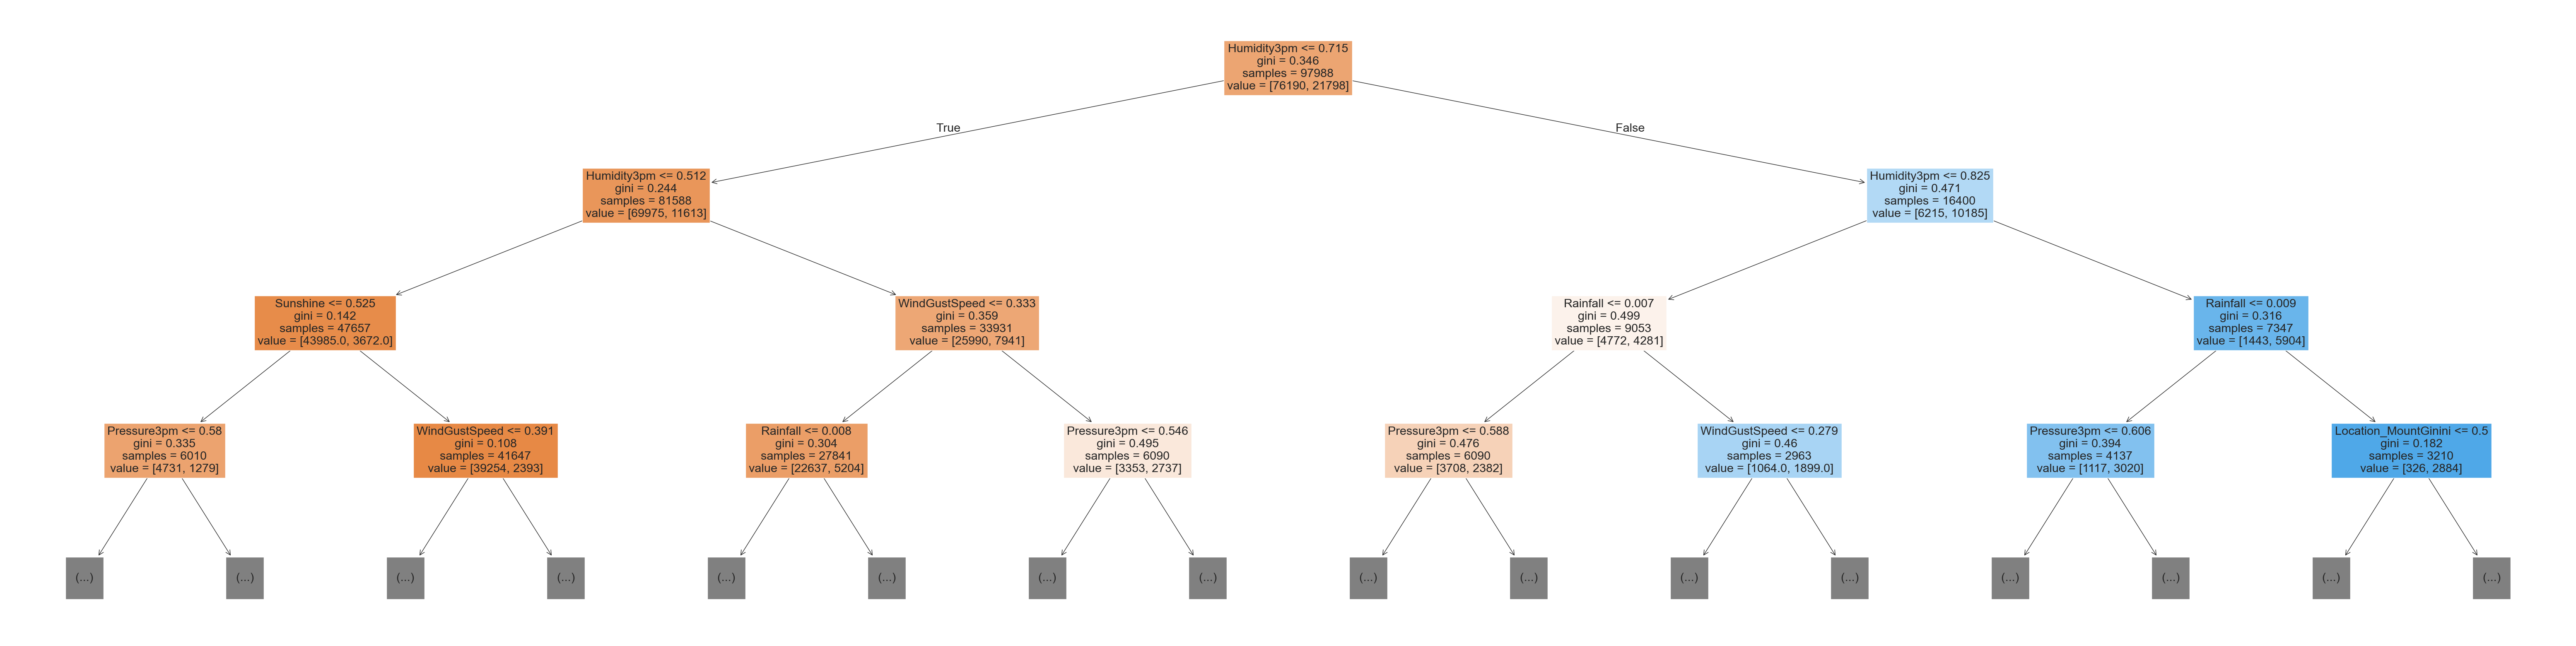

In [62]:
plt.figure(figsize=(80,20))
plot_tree(model, feature_names=X_train.columns, max_depth=3, filled=True)

In [63]:
model.feature_importances_

array([0.04122558, 0.03887034, 0.04342705, 0.02320953, 0.04833551,
       0.06126003, 0.02775848, 0.03084026, 0.03942103, 0.28006643,
       0.03794535, 0.06472083, 0.01474074, 0.0170647 , 0.03865482,
       0.00175004, 0.00175879, 0.00105707, 0.00077429, 0.00163299,
       0.0012234 , 0.00110259, 0.0016417 , 0.00082906, 0.00135243,
       0.00086679, 0.00199216, 0.00153714, 0.00059082, 0.00053696,
       0.00174686, 0.00036217, 0.00133534, 0.00111447, 0.00137645,
       0.00080351, 0.00088233, 0.00149152, 0.00153823, 0.00045646,
       0.00082857, 0.0012906 , 0.00166659, 0.00117223, 0.00074088,
       0.0008236 , 0.00151218, 0.00145357, 0.00204653, 0.0010623 ,
       0.00167803, 0.00140233, 0.00269009, 0.00105264, 0.00034997,
       0.00156362, 0.00035757, 0.00116023, 0.00167361, 0.00140207,
       0.00141996, 0.00261102, 0.00167526, 0.00060368, 0.00236287,
       0.00179357, 0.00212899, 0.00327601, 0.00278792, 0.00192528,
       0.00323519, 0.00267314, 0.00248498, 0.00231233, 0.00224

In [64]:
importance_df = pd.DataFrame({
    'feature': X_train.columns,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=False)

In [65]:
importance_df.head(10)

,feature,importance
9,Humidity3pm,0.280066
11,Pressure3pm,0.064721
5,WindGustSpeed,0.061260
4,Sunshine,0.048336
2,Rainfall,0.043427
0,MinTemp,0.041226
8,Humidity9am,0.039421
1,MaxTemp,0.038870
14,Temp9am,0.038655
10,Pressure9am,0.037945


<Axes: title={'center': 'Feature Importance'}, xlabel='importance', ylabel='feature'>

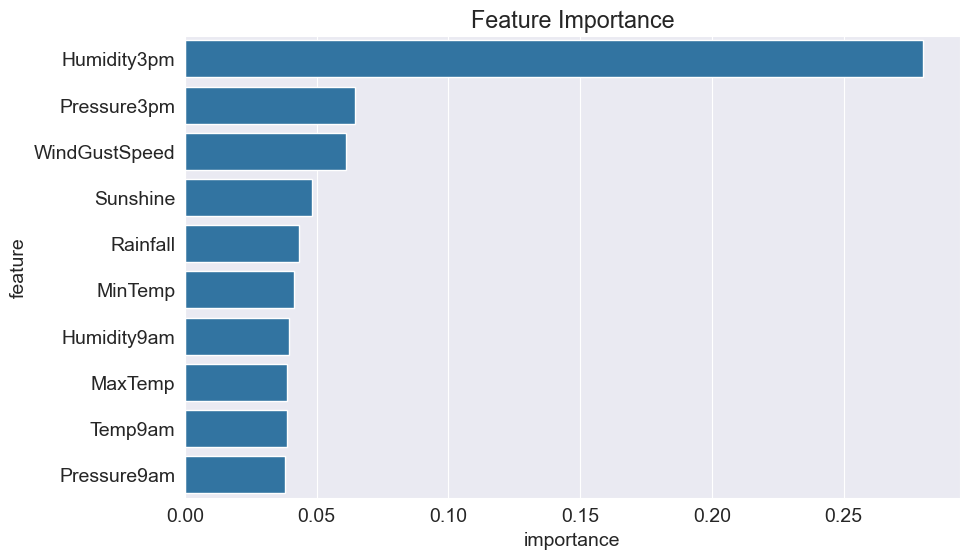

In [66]:
plt.title('Feature Importance')
sns.barplot(data=importance_df.head(10), x='importance', y='feature')

In [67]:
model = DecisionTreeClassifier(max_depth=3, random_state=42)

In [68]:
model.fit(X_train, train_targets)

,criterion,'gini'
,splitter,'best'
,max_depth,3
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [69]:
model.score(X_train, train_targets)

0.8315916234640977

In [70]:
model.score(X_val, val_targets)

0.8348060155655685

model.score(X_val, val_targets)

In [71]:
model.classes_

array(['No', 'Yes'], dtype=object)

[Text(0.5, 0.875, 'Humidity3pm <= 0.715\ngini = 0.346\nsamples = 97988\nvalue = [76190, 21798]\nclass = No'),
 Text(0.25, 0.625, 'Humidity3pm <= 0.512\ngini = 0.244\nsamples = 81588\nvalue = [69975, 11613]\nclass = No'),
 Text(0.375, 0.75, 'True  '),
 Text(0.125, 0.375, 'Sunshine <= 0.525\ngini = 0.142\nsamples = 47657\nvalue = [43985.0, 3672.0]\nclass = No'),
 Text(0.0625, 0.125, 'gini = 0.335\nsamples = 6010\nvalue = [4731, 1279]\nclass = No'),
 Text(0.1875, 0.125, 'gini = 0.108\nsamples = 41647\nvalue = [39254, 2393]\nclass = No'),
 Text(0.375, 0.375, 'WindGustSpeed <= 0.333\ngini = 0.359\nsamples = 33931\nvalue = [25990, 7941]\nclass = No'),
 Text(0.3125, 0.125, 'gini = 0.304\nsamples = 27841\nvalue = [22637, 5204]\nclass = No'),
 Text(0.4375, 0.125, 'gini = 0.495\nsamples = 6090\nvalue = [3353, 2737]\nclass = No'),
 Text(0.75, 0.625, 'Humidity3pm <= 0.825\ngini = 0.471\nsamples = 16400\nvalue = [6215, 10185]\nclass = Yes'),
 Text(0.625, 0.75, '  False'),
 Text(0.625, 0.375, 'Rainf

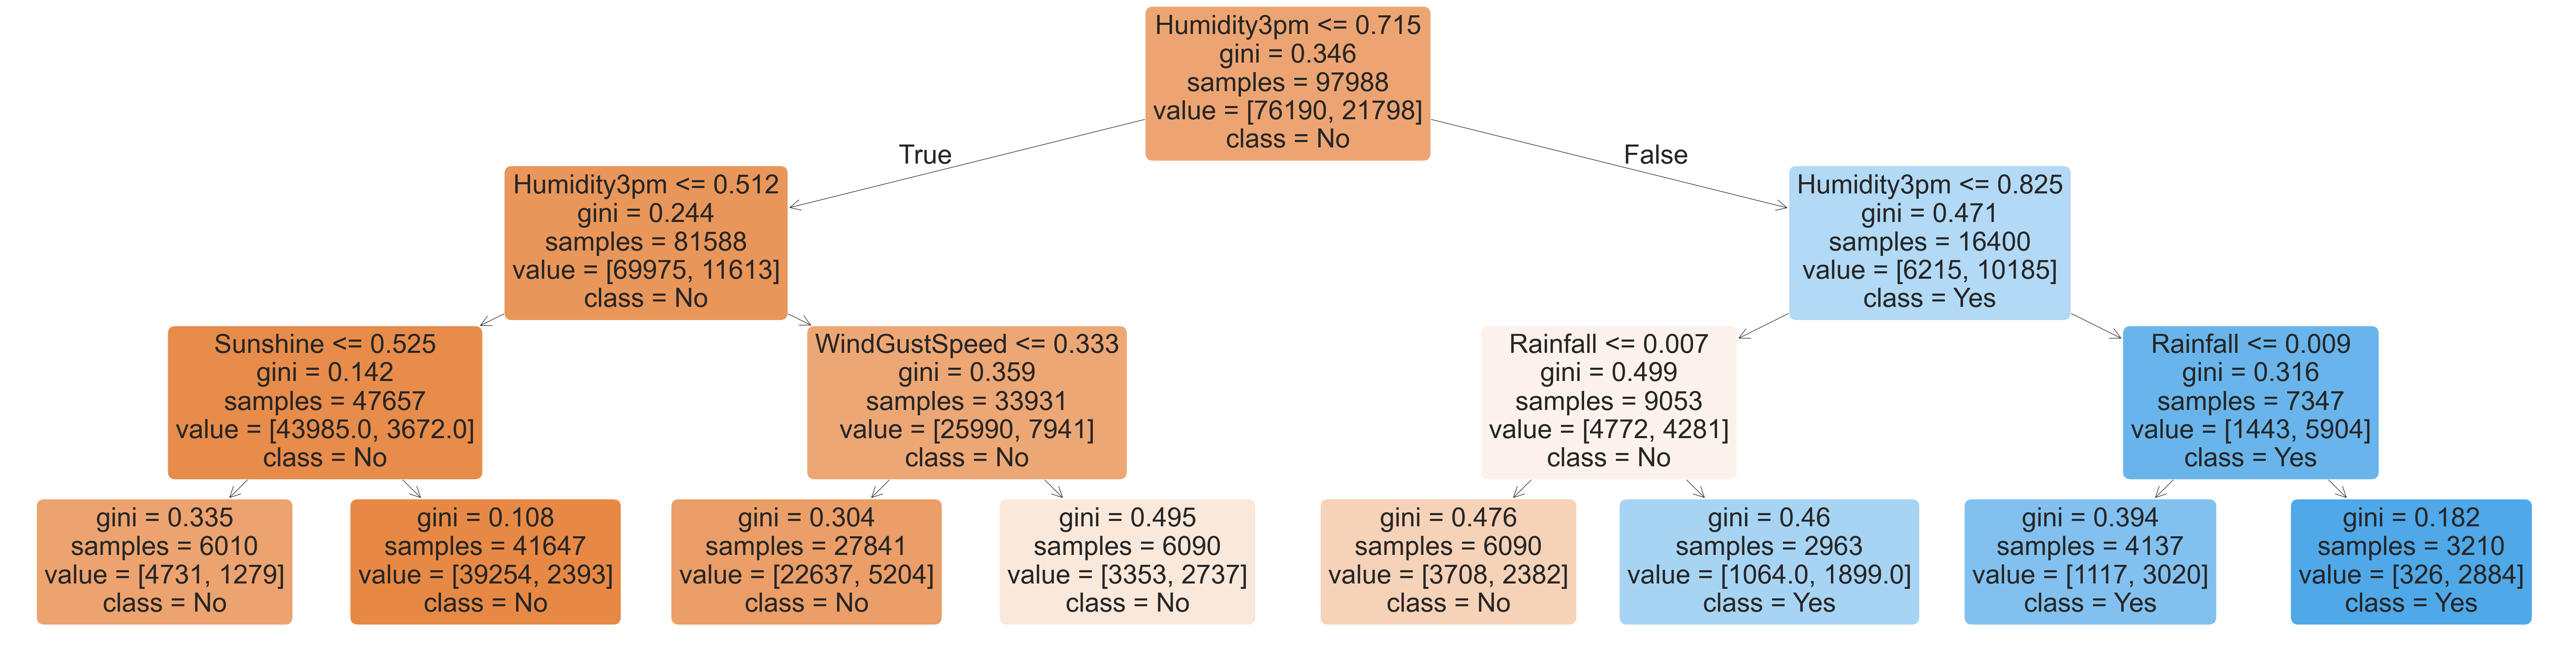

In [72]:
plt.figure(figsize=(80,20))
plot_tree(model, feature_names=X_train.columns, filled=True, rounded=True, class_names=model.classes_)

In [73]:
def max_depth_error(md):
    model = DecisionTreeClassifier(max_depth=md, random_state=42)
    model.fit(X_train, train_targets)
    train_error = 1 - model.score(X_train, train_targets)
    val_error = 1 - model.score(X_val, val_targets)
    return {'Max Depth': md, 'Training Error': train_error, 'Validation Error': val_error}

In [74]:
%%time
errors_df = pd.DataFrame(max_depth_error(md) for md in range(1, 21))

CPU times: total: 32.1 s
Wall time: 1min 16s


In [75]:
errors_df

,Max Depth,Training Error,Validation Error
0,1,0.181941,0.176488
1,2,0.176930,0.170695
2,3,0.168408,0.165194
3,4,0.162153,0.161624
4,5,0.157244,0.158113
5,6,0.153131,0.155890
6,7,0.149120,0.154836
7,8,0.144916,0.154368
8,9,0.139619,0.154544
9,10,0.132057,0.155656


C:\Users\USER\AppData\Local\Temp\ipykernel_17564\1566893896.py:8: UserWarning: Legend does not support handles for str instances.
A proxy artist may be used instead.
See: https://matplotlib.org/stable/users/explain/axes/legend_guide.html#controlling-the-legend-entries
  plt.legend('Training', 'Validation')


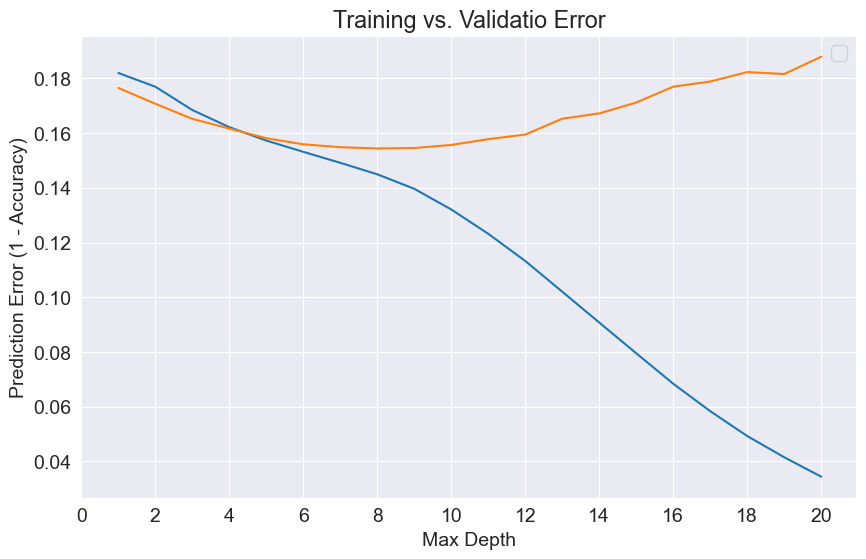

In [76]:
plt.figure()
plt.plot(errors_df['Max Depth'], errors_df['Training Error'])
plt.plot(errors_df['Max Depth'], errors_df['Validation Error'])
plt.title('Training vs. Validatio Error')
plt.xticks(range(0,21,2))
plt.xlabel('Max Depth')
plt.ylabel('Prediction Error (1 - Accuracy)')
plt.legend('Training', 'Validation')

In [77]:
model = DecisionTreeClassifier(max_depth=5, random_state=42).fit(X_train, train_targets)
model.score(X_val, val_targets)

0.8418865937152554

In [78]:
model = DecisionTreeClassifier(max_leaf_nodes=123, random_state=42)

In [79]:
model.fit(X_train, train_targets)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,123
,min_impurity_decrease,0.0
,class_weight,None


In [80]:
model.score(X_train, train_targets)

0.8519206433440829

In [81]:
model.score(X_val, val_targets)

0.8466264848733103

In [82]:
model.tree_.max_depth

11

In [83]:
from sklearn.ensemble import RandomForestClassifier

In [84]:
model = RandomForestClassifier(n_jobs=1, random_state=42)

In [85]:
%%time
model.fit(X_train, train_targets)

C:\Users\USER\anaconda3\Lib\site-packages\sklearn\base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


CPU times: total: 21 s
Wall time: 53 s


,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [86]:
model.score(X_train, train_targets)

0.9999693840062048

In [87]:
model.score(X_val, val_targets)

0.8565744045877465

In [88]:
train_probs = model.predict_proba(X_train)
train_probs

array([[0.96, 0.04],
       [0.97, 0.03],
       [0.98, 0.02],
       ...,
       [0.99, 0.01],
       [1.  , 0.  ],
       [0.96, 0.04]], shape=(97988, 2))

In [89]:
len(model.estimators_)

100

In [90]:
model.estimators_[0]

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,random_state,1608637542
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


[Text(0.5, 0.875, 'Cloud9am <= 0.722\ngini = 0.344\nsamples = 61960\nvalue = [76344, 21644]\nclass = No'),
 Text(0.25, 0.625, 'Pressure3pm <= 0.486\ngini = 0.287\nsamples = 47533\nvalue = [62261, 13056]\nclass = No'),
 Text(0.375, 0.75, 'True  '),
 Text(0.125, 0.375, 'Rainfall <= 0.001\ngini = 0.447\nsamples = 5071\nvalue = [5316, 2708]\nclass = No'),
 Text(0.0625, 0.125, '\n  (...)  \n'),
 Text(0.1875, 0.125, '\n  (...)  \n'),
 Text(0.375, 0.375, 'MaxTemp <= 0.468\ngini = 0.26\nsamples = 42462\nvalue = [56945, 10348]\nclass = No'),
 Text(0.3125, 0.125, '\n  (...)  \n'),
 Text(0.4375, 0.125, '\n  (...)  \n'),
 Text(0.75, 0.625, 'MaxTemp <= 0.322\ngini = 0.471\nsamples = 14427\nvalue = [14083.0, 8588.0]\nclass = No'),
 Text(0.625, 0.75, '  False'),
 Text(0.625, 0.375, 'Cloud3pm <= 0.833\ngini = 0.496\nsamples = 792\nvalue = [576, 684]\nclass = Yes'),
 Text(0.5625, 0.125, '\n  (...)  \n'),
 Text(0.6875, 0.125, '\n  (...)  \n'),
 Text(0.875, 0.375, 'Location_CoffsHarbour <= 0.5\ngini = 0.

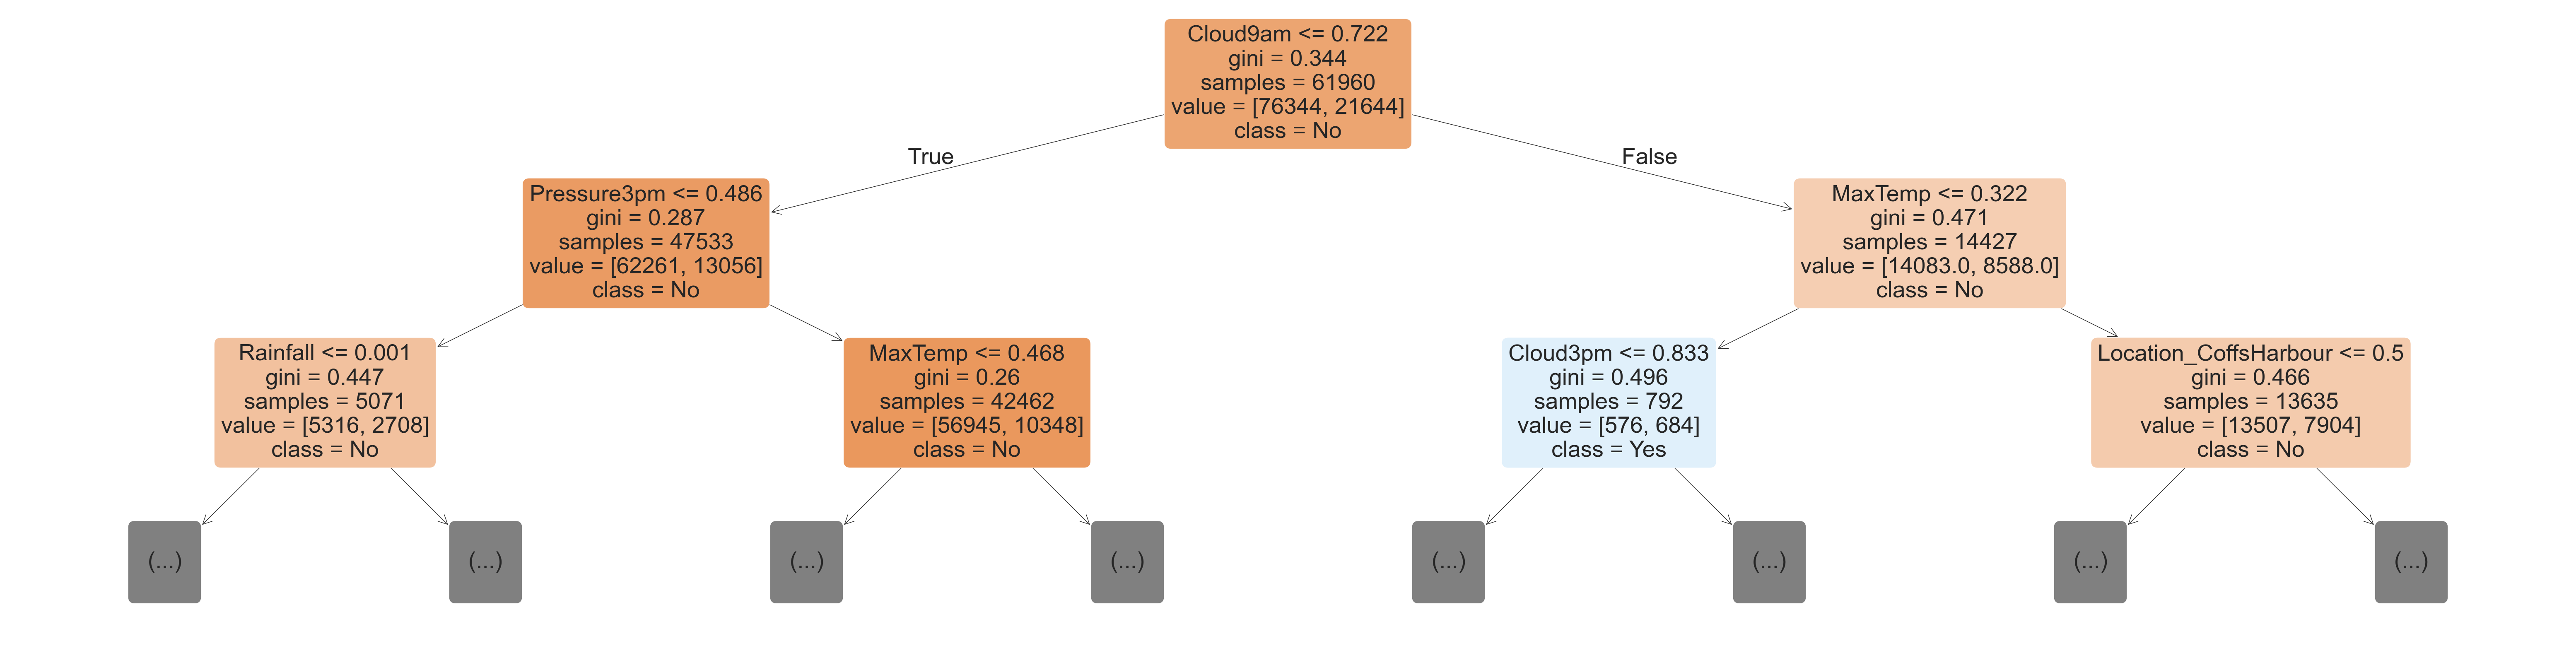

In [91]:
plt.figure(figsize=(80,20))
plot_tree(model.estimators_[0], max_depth=2, feature_names=X_train.columns, filled=True, rounded=True, class_names=model.classes_)

[Text(0.5, 0.875, 'Rainfall <= 0.002\ngini = 0.345\nsamples = 61821\nvalue = [76261, 21727]\nclass = No'),
 Text(0.25, 0.625, 'WindDir3pm_N <= 0.5\ngini = 0.249\nsamples = 46204\nvalue = [62511, 10670]\nclass = No'),
 Text(0.375, 0.75, 'True  '),
 Text(0.125, 0.375, 'Sunshine <= 0.403\ngini = 0.241\nsamples = 43056\nvalue = [58605, 9547]\nclass = No'),
 Text(0.0625, 0.125, '\n  (...)  \n'),
 Text(0.1875, 0.125, '\n  (...)  \n'),
 Text(0.375, 0.375, 'Sunshine <= 0.417\ngini = 0.347\nsamples = 3148\nvalue = [3906, 1123]\nclass = No'),
 Text(0.3125, 0.125, '\n  (...)  \n'),
 Text(0.4375, 0.125, '\n  (...)  \n'),
 Text(0.75, 0.625, 'Cloud3pm <= 0.722\ngini = 0.494\nsamples = 15617\nvalue = [13750, 11057]\nclass = No'),
 Text(0.625, 0.75, '  False'),
 Text(0.625, 0.375, 'Cloud3pm <= 0.389\ngini = 0.464\nsamples = 10398\nvalue = [10460, 6052]\nclass = No'),
 Text(0.5625, 0.125, '\n  (...)  \n'),
 Text(0.6875, 0.125, '\n  (...)  \n'),
 Text(0.875, 0.375, 'Humidity9am <= 0.805\ngini = 0.479\ns

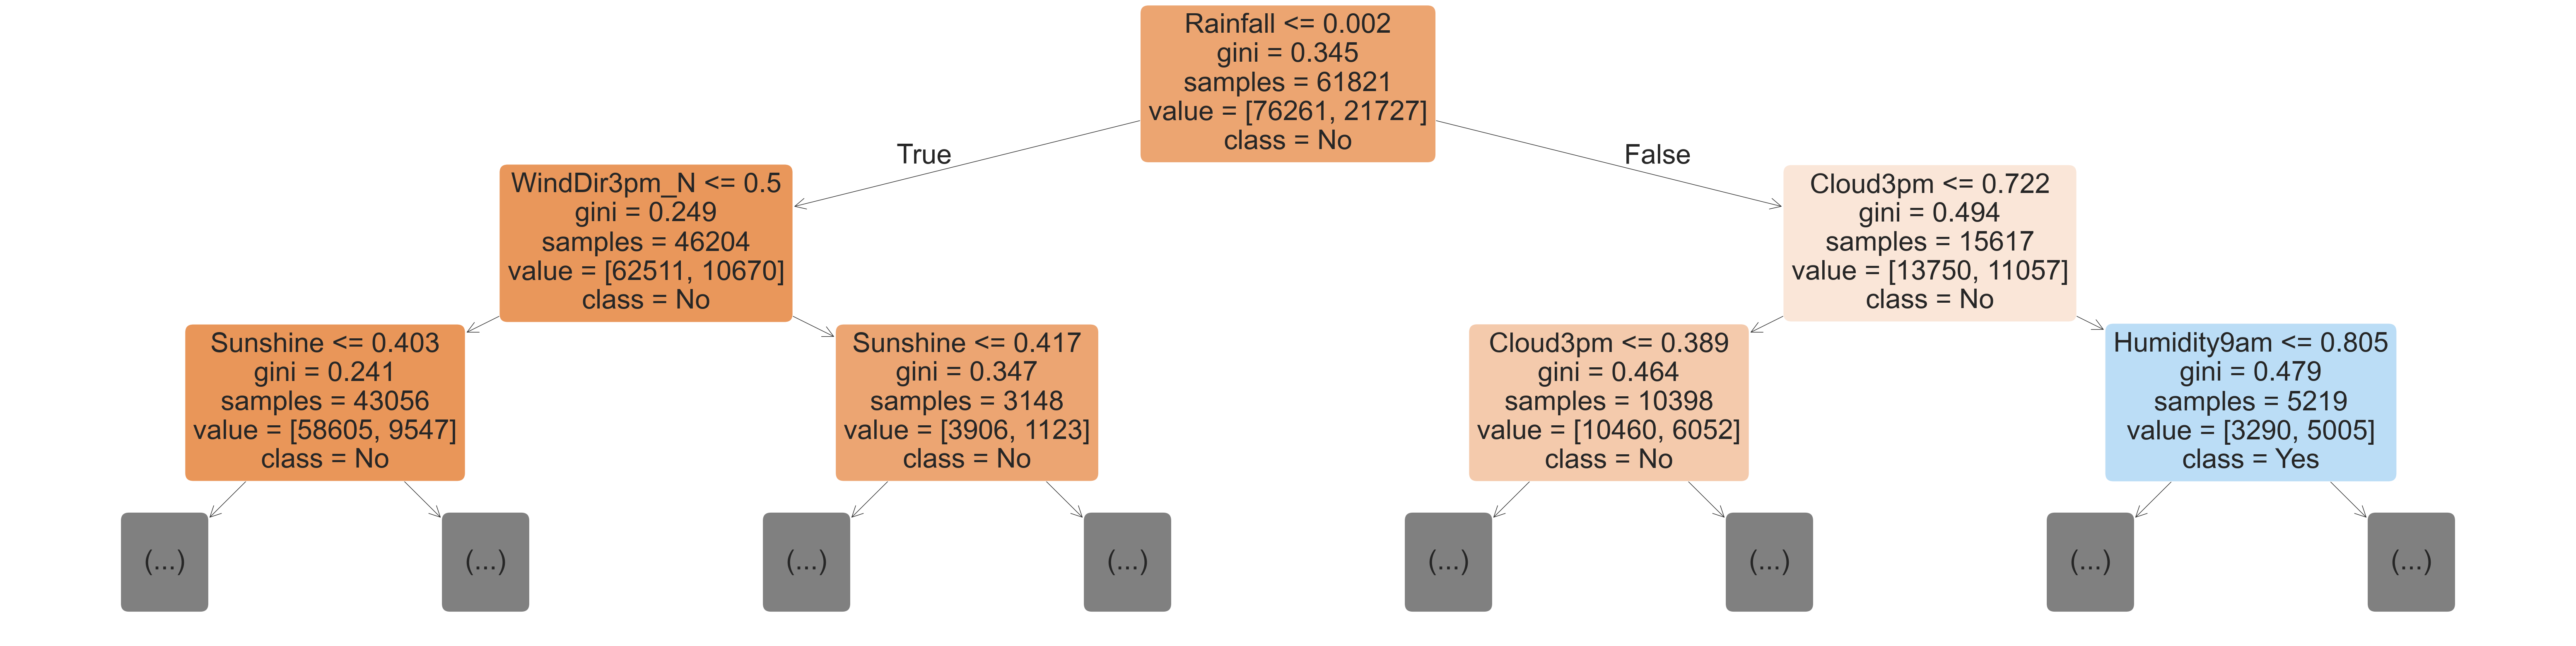

In [92]:
plt.figure(figsize=(80,20))
plot_tree(model.estimators_[15], max_depth=2, feature_names=X_train.columns, filled=True, rounded=True, class_names=model.classes_)

In [93]:
importance_df = pd.DataFrame({
    'feature': X_train.columns,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=False)

In [94]:
importance_df.head(10)

,feature,importance
9,Humidity3pm,0.149998
11,Pressure3pm,0.054639
4,Sunshine,0.054286
8,Humidity9am,0.053871
5,WindGustSpeed,0.050907
10,Pressure9am,0.050807
2,Rainfall,0.046521
1,MaxTemp,0.046347
0,MinTemp,0.042834
14,Temp9am,0.041120


<Axes: title={'center': 'Feature Importance'}, xlabel='importance', ylabel='feature'>

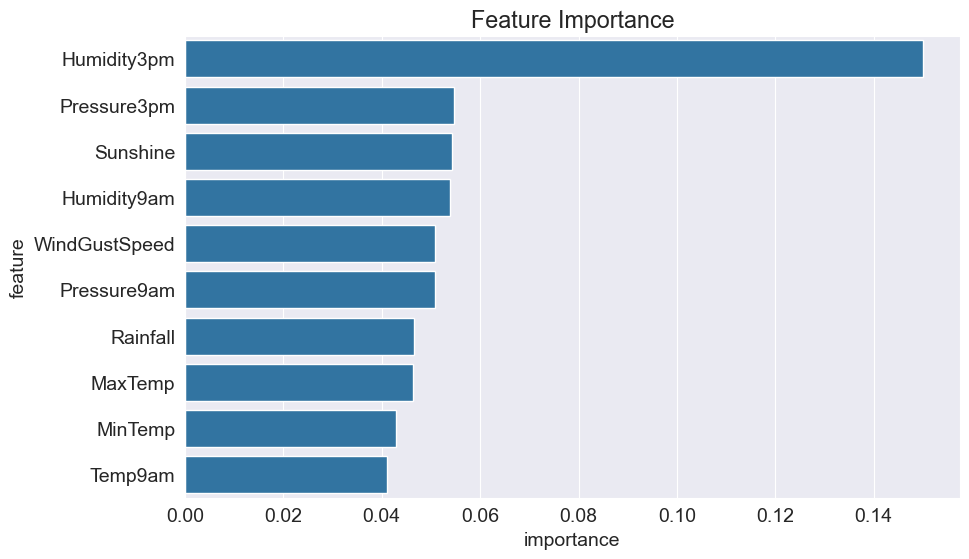

In [95]:
plt.title('Feature Importance')
sns.barplot(data=importance_df.head(10), x='importance', y='feature')

In [96]:
# improving random forest by hyperparameter tuning
#?RandomForestClassifier

In [97]:
base_model = RandomForestClassifier(random_state=42, n_jobs=-1).fit(X_train, train_targets)

C:\Users\USER\anaconda3\Lib\site-packages\sklearn\base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


In [98]:
base_train_acc = base_model.score(X_train,train_targets)
base_val_acc = base_model.score(X_val, val_targets)

In [99]:
base_accs = base_train_acc, base_val_acc
base_accs

(0.9999693840062048, 0.8565744045877465)

In [100]:
model = RandomForestClassifier(random_state=42, n_jobs=-1, n_estimators=300)

In [101]:
model.fit(X_train, train_targets)

C:\Users\USER\anaconda3\Lib\site-packages\sklearn\base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


,n_estimators,300
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [102]:
model.score(X_train, train_targets), model.score(X_val, val_targets)

(0.9999795893374699, 0.8568669904617006)

In [103]:
base_accs

(0.9999693840062048, 0.8565744045877465)

In [104]:
def test_params(**params):
    model = RandomForestClassifier(random_state=42, n_jobs=-1, **params).fit(X_train, train_targets)
    return model.score(X_train, train_targets), model.score(X_val, val_targets)

In [105]:
test_params(max_depth=5)

C:\Users\USER\anaconda3\Lib\site-packages\sklearn\base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


(0.8283157121280157, 0.8321142255251917)

In [106]:
test_params(max_depth=26)

C:\Users\USER\anaconda3\Lib\site-packages\sklearn\base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


(0.9814875290851941, 0.8563403358885833)

In [107]:
test_params(max_leaf_nodes=2**5)

C:\Users\USER\anaconda3\Lib\site-packages\sklearn\base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


(0.834551169530963, 0.8356252560126397)

In [108]:
test_params(max_features='log2')

C:\Users\USER\anaconda3\Lib\site-packages\sklearn\base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


(0.9999693840062048, 0.8556381297910937)

In [109]:
test_params(max_features=3)

C:\Users\USER\anaconda3\Lib\site-packages\sklearn\base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


(0.9999795893374699, 0.8538240973725788)

In [110]:
test_params(max_features=30)

C:\Users\USER\anaconda3\Lib\site-packages\sklearn\base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


(0.9999693840062048, 0.8575691965591902)

In [111]:
base_accs

(0.9999693840062048, 0.8565744045877465)

In [112]:
test_params(min_samples_split=3, min_samples_leaf=2)

C:\Users\USER\anaconda3\Lib\site-packages\sklearn\base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


(0.9594440135526799, 0.8580958511323074)

In [113]:
test_params(min_samples_split=100, min_samples_leaf=60)

C:\Users\USER\anaconda3\Lib\site-packages\sklearn\base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


(0.8510123688614932, 0.8472701737960091)

In [114]:
base_accs

(0.9999693840062048, 0.8565744045877465)

In [115]:
test_params(min_impurity_decrease=1e-6)

C:\Users\USER\anaconda3\Lib\site-packages\sklearn\base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


(0.9879475037759725, 0.8565158874129557)

In [116]:
test_params(min_impurity_decrease=1e-2)

C:\Users\USER\anaconda3\Lib\site-packages\sklearn\base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


(0.7775441890843777, 0.7906255485985136)

In [117]:
test_params(bootstrap=False)

C:\Users\USER\anaconda3\Lib\site-packages\sklearn\base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


(0.9999795893374699, 0.857627713733981)

In [118]:
test_params(class_weight='balanced')

C:\Users\USER\anaconda3\Lib\site-packages\sklearn\base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


(0.9999693840062048, 0.8564573702381649)

In [119]:
test_params(class_weight={'No': 1, 'Yes':2})

C:\Users\USER\anaconda3\Lib\site-packages\sklearn\base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


(0.9999795893374699, 0.8559307156650476)

In [120]:
model = RandomForestClassifier(
    n_jobs=-1,
    random_state=42,
    n_estimators=500,
    max_features=7,
    max_depth=30,
    class_weight={'No': 1, 'Yes': 1.5}
)

In [121]:
model.fit(X_train, train_targets)

C:\Users\USER\anaconda3\Lib\site-packages\sklearn\base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


,n_estimators,500
,criterion,'gini'
,max_depth,30
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,7
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [122]:
model.score(X_train, train_targets), model.score(X_val, val_targets)

(0.9910805404743438, 0.8585639885306338)

In [123]:
model.score(X_test, test_targets)

0.847024504084014

In [130]:
def predict_input(model, single_input):
    input_df = pd.DataFrame([single_input])
    input_df[numeric_cols] = imputer.transform(input_df[numeric_cols])
    input_df[numeric_cols] = scaler.transform(input_df[numeric_cols])
    input_df[encoder_cols] = encoder.transform(input_df[categorical_cols])
    X_input = input_df[numeric_cols + encoder_cols]
    pred = model.predict(X_input)[0]
    prob = model.predict_proba(X_input)[0][list(model.classes_).index(pred)]
    return pred, prob

In [131]:
new_input = {
    'Date': '2021-06-19',
    'Location': 'Launceston',
    'MinTemp': 23.2,
    'MaxTemp': 33.2,
    'Rainfall': 10.2,
    'Evaporation': 4.2,
    'Sunshine': np.nan,
    'WindGustDir': 'NNW',
    'WindGustSpeed': 52.0,
    'WindDir9am': 'NW',
    'WindDir3pm': 'NNE',
    'WindSpeed9am': 13.0,
    'WindSpeed3pm': 20.0,
    'Humidity9am': 89.0,
    'Humidity3pm': 58.0,
    'Pressure9am': 1004.8,
    'Pressure3pm': 1001.5,
    'Cloud9am': 8.0,
    'Cloud3pm': 5.0,
    'Temp9am': 25.7,
    'Temp3pm': 33.0,
    'RainToday': 'Yes'
    
}

In [132]:
predict_input(model, new_input)

C:\Users\USER\AppData\Local\Temp\ipykernel_17564\1248598105.py:5: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  input_df[encoder_cols] = encoder.transform(input_df[categorical_cols])
C:\Users\USER\AppData\Local\Temp\ipykernel_17564\1248598105.py:5: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  input_df[encoder_cols] = encoder.transform(input_df[categorical_cols])
C:\Users\USER\AppData\Local\Temp\ipykernel_17564\1248598105.py:5: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.inse

('Yes', np.float64(0.7808001102594205))

In [133]:
import joblib

In [134]:
aussie_rain = {
    'model': model,
    'imputer': imputer,
    'scaler': scaler,
    'encoder': encoder,
    'input_cols': input_cols,
    'target_cols': target_col,
    'numeric_cols': numeric_cols,
    'categorical_cols': categorical_cols,
    'encoded_cols': encoder_cols
}

In [135]:
joblib.dump(aussie_rain, 'aussie_rain2.joblib')

['aussie_rain2.joblib']

In [139]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

preds = model.predict(X_test)

print(classification_report(test_targets, preds))
print(confusion_matrix(test_targets, preds))
print(roc_auc_score(test_targets, model.predict_proba(X_test)[:, 1]))

              precision    recall  f1-score   support

          No       0.86      0.96      0.91     19885
         Yes       0.76      0.48      0.59      5825

    accuracy                           0.85     25710
   macro avg       0.81      0.72      0.75     25710
weighted avg       0.84      0.85      0.83     25710

[[19004   881]
 [ 3052  2773]]
0.8720378312636717


In [141]:
import numpy as np
from sklearn.metrics import classification_report

test_targets_binary = (test_targets == 'Yes').astype(int)

for t in [0.3, 0.35, 0.4, 0.45, 0.5]:
    preds_t = (probs >= t).astype(int)
    print(f"--- Threshold: {t} ---")
    print(classification_report(test_targets_binary, preds_t))

--- Threshold: 0.3 ---
              precision    recall  f1-score   support

           0       0.91      0.85      0.88     19885
           1       0.58      0.72      0.65      5825

    accuracy                           0.82     25710
   macro avg       0.75      0.79      0.76     25710
weighted avg       0.84      0.82      0.83     25710

--- Threshold: 0.35 ---
              precision    recall  f1-score   support

           0       0.90      0.89      0.89     19885
           1       0.63      0.66      0.65      5825

    accuracy                           0.84     25710
   macro avg       0.77      0.77      0.77     25710
weighted avg       0.84      0.84      0.84     25710

--- Threshold: 0.4 ---
              precision    recall  f1-score   support

           0       0.89      0.92      0.90     19885
           1       0.68      0.60      0.64      5825

    accuracy                           0.84     25710
   macro avg       0.78      0.76      0.77     25710
weig

In [142]:
final_threshold = 0.35
final_preds = (probs >= final_threshold).astype(int)
print(classification_report(test_targets_binary, final_preds))

              precision    recall  f1-score   support

           0       0.90      0.89      0.89     19885
           1       0.63      0.66      0.65      5825

    accuracy                           0.84     25710
   macro avg       0.77      0.77      0.77     25710
weighted avg       0.84      0.84      0.84     25710

